<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Unified%20Model/MergeDataSets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

pdf_df = pd.read_csv("/content/PDF_unified_features (3).csv")
excel_df = pd.read_csv("/content/excel_unified_features (2).csv")
word_df = pd.read_csv("/content/Word_unified_features (1).csv")
html_df = pd.read_csv("/content/html_unified_features (1).csv")


In [ ]:
#Make sure the columns are identical

print(pdf_df.columns.equals(excel_df.columns))
print(pdf_df.columns.equals(word_df.columns))
print(pdf_df.columns.equals(html_df.columns))

True
True
True


In [ ]:

print("\nExcel Columns:")
print(excel_df.columns.tolist())

print("\nPDF Columns:")
print(pdf_df.columns.tolist())

print("\nWord Columns:")
print(word_df.columns.tolist())

print("\nHTML Columns:")
print(html_df.columns.tolist())


Excel Columns:
['file_size', 'text_size', 'embedded_objects', 'active_content_score', 'active_content_density', 'external_reference_count', 'obfuscation_score', 'structural_complexity_score', 'label']
PDF Columns:
['file_size', 'text_size', 'embedded_objects', 'active_content_score', 'active_content_density', 'external_reference_count', 'obfuscation_score', 'structural_complexity_score', 'label']

Word Columns:
['file_size', 'text_size', 'embedded_objects', 'active_content_score', 'active_content_density', 'external_reference_count', 'obfuscation_score', 'structural_complexity_score', 'label']

HTML Columns:
['file_size', 'text_size', 'embedded_objects', 'active_content_score', 'active_content_density', 'external_reference_count', 'obfuscation_score', 'structural_complexity_score', 'label']


# Leave-One-Format-Out Model

In [ ]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Train = PDF + Word + HTML
# Test = Excel

train_df = pd.concat([pdf_df, word_df, html_df], ignore_index=True)

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = excel_df.drop(columns=["label"])
y_test = excel_df["label"]

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
display(results_df)

Decision Tree
Accuracy : 0.8245061551674778
Precision: 0.9993429697766097
Recall   : 0.38293051359516617
F1 Score : 0.5536949399344739
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     10000
           1       1.00      0.38      0.55      3972

    accuracy                           0.82     13972
   macro avg       0.90      0.69      0.72     13972
weighted avg       0.86      0.82      0.79     13972

Random Forest
Accuracy : 0.8287288863441168
Precision: 0.9719067543335326
Recall   : 0.4093655589123867
F1 Score : 0.5760850310008857
              precision    recall  f1-score   support

           0       0.81      1.00      0.89     10000
           1       0.97      0.41      0.58      3972

    accuracy                           0.83     13972
   macro avg       0.89      0.70      0.73     13972
weighted avg       0.86      0.83      0.80     13972

XGBoost
Accuracy : 0.787288863441168
Precision: 0.6795977011494253
Recall   :

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.824506,0.999343,0.382931,0.553695
1,Random Forest,0.828729,0.971907,0.409366,0.576085
2,XGBoost,0.787289,0.679598,0.476334,0.560095


In [ ]:
train_df = pd.concat([pdf_df, excel_df, word_df], ignore_index=True)

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = html_df.drop(columns=["label"])
y_test = html_df["label"]

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Macro:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Accuracy: 0.3756002595717067
F1 Macro: 0.27304462685158976
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      9621
           1       0.38      1.00      0.55      5789

    accuracy                           0.38     15410
   macro avg       0.19      0.50      0.27     15410
weighted avg       0.14      0.38      0.21     15410



In [ ]:
train_df = pd.concat([pdf_df, word_df, html_df], ignore_index=True)

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = excel_df.drop(columns=["label"])
y_test = excel_df["label"]

Decision Tree  |  Test Format = PDF
Accuracy : 0.44929329772682863
Precision: 0.41771889877872076
Recall   : 0.9973640856672158
F1 Score : 0.5888245878519671
ROC AUC  : 0.5441414848243437

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.09      0.17      9283
           1       0.42      1.00      0.59      6070

    accuracy                           0.45     15353
   macro avg       0.70      0.54      0.38     15353
weighted avg       0.76      0.45      0.33     15353



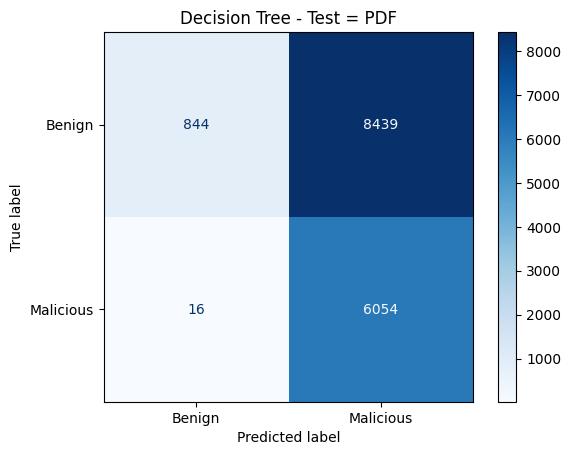

Random Forest  |  Test Format = PDF
Accuracy : 0.8945482967498208
Precision: 0.8306343782498886
Recall   : 0.9210873146622734
F1 Score : 0.8735255058198578
ROC AUC  : 0.939202703707562

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      9283
           1       0.83      0.92      0.87      6070

    accuracy                           0.89     15353
   macro avg       0.89      0.90      0.89     15353
weighted avg       0.90      0.89      0.90     15353



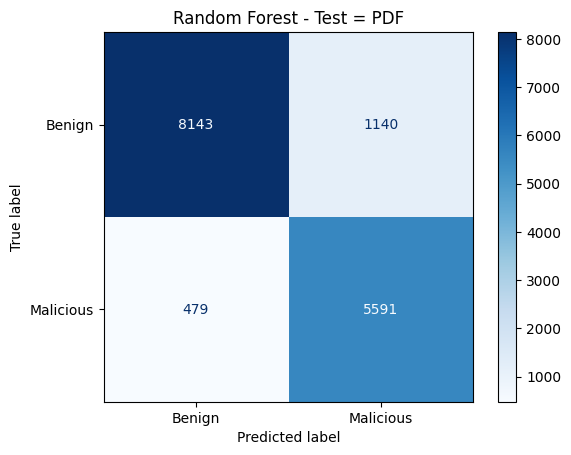

XGBoost  |  Test Format = PDF
Accuracy : 0.4074773659871035
Precision: 0.39937504155308823
Recall   : 0.9896210873146623
F1 Score : 0.5690872057221353
ROC AUC  : 0.9673558386741207

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.03      0.05      9283
           1       0.40      0.99      0.57      6070

    accuracy                           0.41     15353
   macro avg       0.60      0.51      0.31     15353
weighted avg       0.64      0.41      0.26     15353



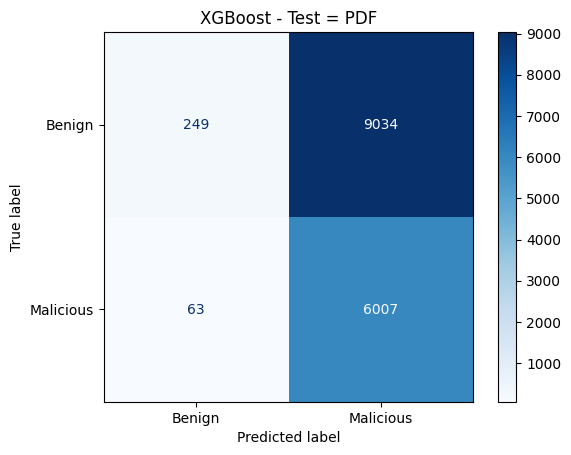


Final Results



,Test Format,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,PDF,Decision Tree,0.449293,0.417719,0.997364,0.588825,0.544141
1,PDF,Random Forest,0.894548,0.830634,0.921087,0.873526,0.939203
2,PDF,XGBoost,0.407477,0.399375,0.989621,0.569087,0.967356


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# The left format

test_format = "PDF"

datasets = {
    "PDF": pdf_df,
    "Word": word_df,
    "Excel": excel_df,
    "HTML": html_df
}

#==================================================
# تجهيز بيانات التدريب والاختبار
#==================================================

train_list = [df for name, df in datasets.items() if name != test_format]
train_df = pd.concat(train_list, ignore_index=True)

test_df = datasets[test_format]

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

#==================================================
# Models
#==================================================

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

#==================================================
# Training & Evaluation
#==================================================

for name, model in models.items():

    print("="*70)
    print(f"{name}  |  Test Format = {test_format}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    if roc is not None:
        print("ROC AUC  :", roc)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign","Malicious"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"{name} - Test = {test_format}")
    plt.show()

    results.append({
        "Test Format": test_format,
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    })

#==================================================
# Final Table
#==================================================

results_df = pd.DataFrame(results)

print("\nFinal Results\n")
display(results_df)

Decision Tree  |  Test Format = Excel
Accuracy : 0.8245061551674778
Precision: 0.9993429697766097
Recall   : 0.38293051359516617
F1 Score : 0.5536949399344739
ROC AUC  : 0.6914152567975831

Classification Report

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     10000
           1       1.00      0.38      0.55      3972

    accuracy                           0.82     13972
   macro avg       0.90      0.69      0.72     13972
weighted avg       0.86      0.82      0.79     13972



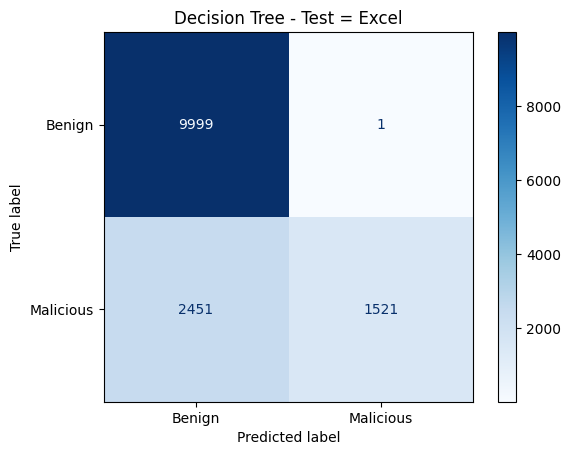

Random Forest  |  Test Format = Excel
Accuracy : 0.8287288863441168
Precision: 0.9719067543335326
Recall   : 0.4093655589123867
F1 Score : 0.5760850310008857
ROC AUC  : 0.6465527819738168

Classification Report

              precision    recall  f1-score   support

           0       0.81      1.00      0.89     10000
           1       0.97      0.41      0.58      3972

    accuracy                           0.83     13972
   macro avg       0.89      0.70      0.73     13972
weighted avg       0.86      0.83      0.80     13972



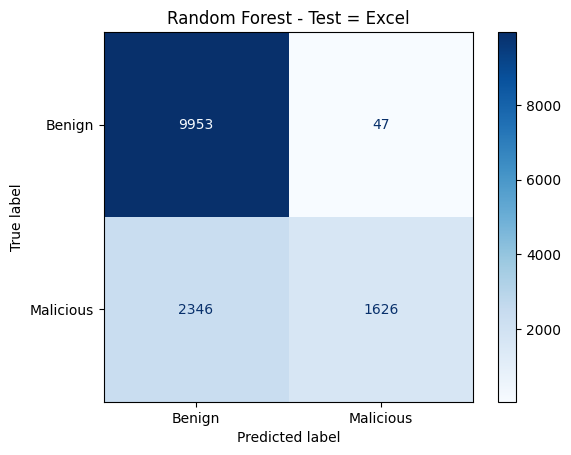

XGBoost  |  Test Format = Excel
Accuracy : 0.787288863441168
Precision: 0.6795977011494253
Recall   : 0.47633434038267874
F1 Score : 0.5600947306098283
ROC AUC  : 0.8898810926485399

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     10000
           1       0.68      0.48      0.56      3972

    accuracy                           0.79     13972
   macro avg       0.75      0.69      0.71     13972
weighted avg       0.78      0.79      0.77     13972



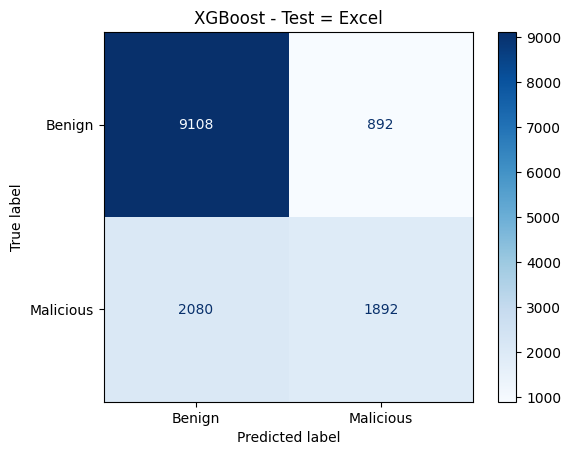


Final Results



,Test Format,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Excel,Decision Tree,0.824506,0.999343,0.382931,0.553695,0.691415
1,Excel,Random Forest,0.828729,0.971907,0.409366,0.576085,0.646553
2,Excel,XGBoost,0.787289,0.679598,0.476334,0.560095,0.889881


In [ ]:


test_format = "Excel"      # PDF / Word / Excel / HTML

datasets = {
    "PDF": pdf_df,
    "Word": word_df,
    "Excel": excel_df,
    "HTML": html_df
}

#==================================================
# تجهيز بيانات التدريب والاختبار
#==================================================

train_list = [df for name, df in datasets.items() if name != test_format]
train_df = pd.concat(train_list, ignore_index=True)

test_df = datasets[test_format]

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

#==================================================
# Models
#==================================================

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

#==================================================
# Training & Evaluation
#==================================================

for name, model in models.items():

    print("="*70)
    print(f"{name}  |  Test Format = {test_format}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    if roc is not None:
        print("ROC AUC  :", roc)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign","Malicious"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"{name} - Test = {test_format}")
    plt.show()

    results.append({
        "Test Format": test_format,
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    })

#==================================================
# Final Table
#==================================================

results_df = pd.DataFrame(results)

print("\nFinal Results\n")
display(results_df)

Decision Tree  |  Test Format = Word
Accuracy : 0.3866305329719964
Precision: 0.4928982725527831
Recall   : 0.642
F1 Score : 0.5576547231270358
ROC AUC  : 0.321

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6605
           1       0.49      0.64      0.56     10000

    accuracy                           0.39     16605
   macro avg       0.25      0.32      0.28     16605
weighted avg       0.30      0.39      0.34     16605



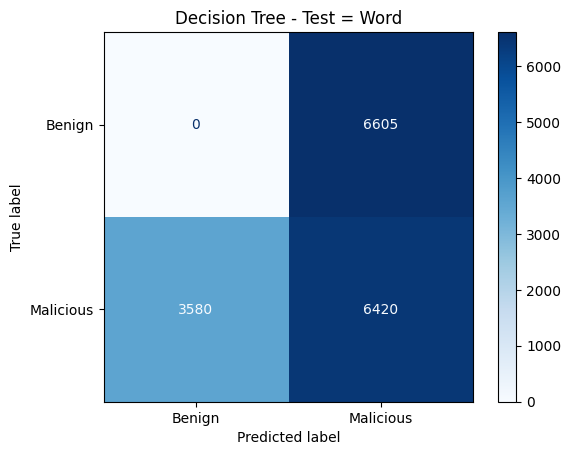

Random Forest  |  Test Format = Word
Accuracy : 0.6022282445046673
Precision: 0.6022282445046673
Recall   : 1.0
F1 Score : 0.7517383950385266
ROC AUC  : 0.009999803179409544

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6605
           1       0.60      1.00      0.75     10000

    accuracy                           0.60     16605
   macro avg       0.30      0.50      0.38     16605
weighted avg       0.36      0.60      0.45     16605



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


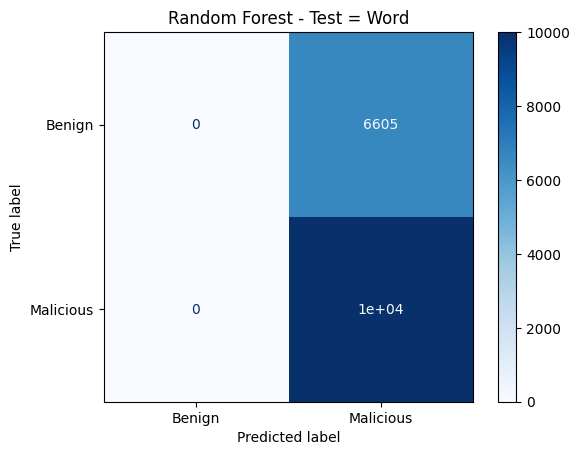

XGBoost  |  Test Format = Word
Accuracy : 0.6022282445046673
Precision: 0.6022282445046673
Recall   : 1.0
F1 Score : 0.7517383950385266
ROC AUC  : 0.941152535957608

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6605
           1       0.60      1.00      0.75     10000

    accuracy                           0.60     16605
   macro avg       0.30      0.50      0.38     16605
weighted avg       0.36      0.60      0.45     16605



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


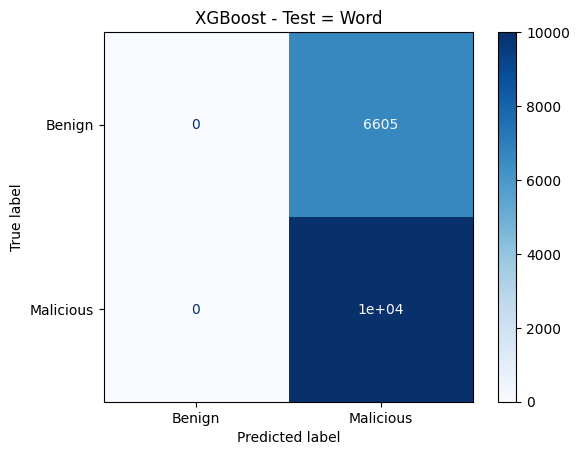


Final Results



,Test Format,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Word,Decision Tree,0.386631,0.492898,0.642,0.557655,0.321000
1,Word,Random Forest,0.602228,0.602228,1.000,0.751738,0.010000
2,Word,XGBoost,0.602228,0.602228,1.000,0.751738,0.941153


In [ ]:

test_format = "Word"      # PDF / Word / Excel / HTML

datasets = {
    "PDF": pdf_df,
    "Word": word_df,
    "Excel": excel_df,
    "HTML": html_df
}

#==================================================
# تجهيز بيانات التدريب والاختبار
#==================================================

train_list = [df for name, df in datasets.items() if name != test_format]
train_df = pd.concat(train_list, ignore_index=True)

test_df = datasets[test_format]

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

#==================================================
# Models
#==================================================

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

#==================================================
# Training & Evaluation
#==================================================

for name, model in models.items():

    print("="*70)
    print(f"{name}  |  Test Format = {test_format}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    if roc is not None:
        print("ROC AUC  :", roc)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign","Malicious"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"{name} - Test = {test_format}")
    plt.show()

    results.append({
        "Test Format": test_format,
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    })

#==================================================
# Final Table
#==================================================

results_df = pd.DataFrame(results)

print("\nFinal Results\n")
display(results_df)

Decision Tree  |  Test Format = HTML
Accuracy : 0.3630759247242051
Precision: 0.36411502632644793
Recall   : 0.9317671445845569
F1 Score : 0.523613066058341
ROC AUC  : 0.47632947188691516

Classification Report

              precision    recall  f1-score   support

           0       0.34      0.02      0.04      9621
           1       0.36      0.93      0.52      5789

    accuracy                           0.36     15410
   macro avg       0.35      0.48      0.28     15410
weighted avg       0.35      0.36      0.22     15410



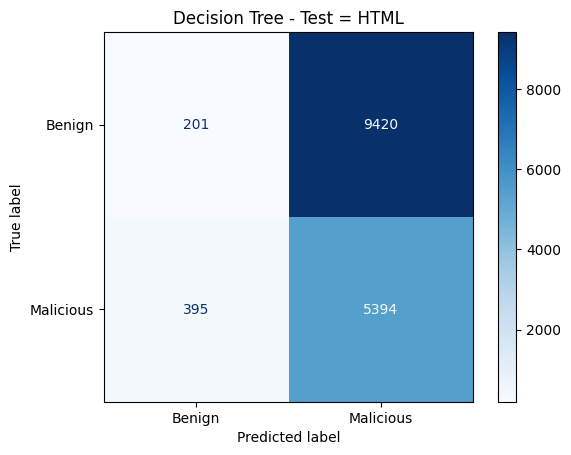

Random Forest  |  Test Format = HTML
Accuracy : 0.3756651524983777
Precision: 0.3756651524983777
Recall   : 1.0
F1 Score : 0.5461578376338506
ROC AUC  : 0.3225240142603498

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      9621
           1       0.38      1.00      0.55      5789

    accuracy                           0.38     15410
   macro avg       0.19      0.50      0.27     15410
weighted avg       0.14      0.38      0.21     15410



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


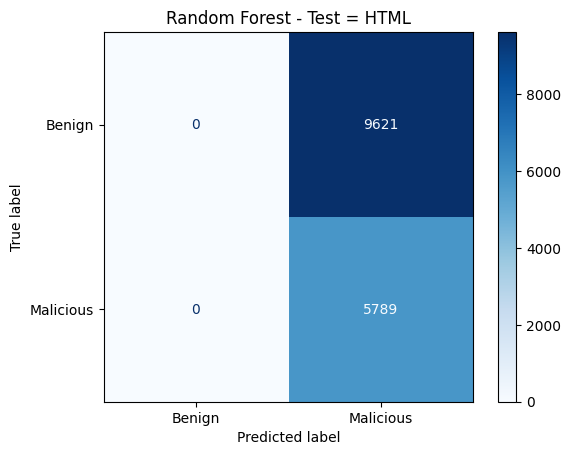

XGBoost  |  Test Format = HTML
Accuracy : 0.3756002595717067
Precision: 0.37562463495359855
Recall   : 0.999827258593885
F1 Score : 0.5460892537031795
ROC AUC  : 0.30325540255884587

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      9621
           1       0.38      1.00      0.55      5789

    accuracy                           0.38     15410
   macro avg       0.19      0.50      0.27     15410
weighted avg       0.14      0.38      0.21     15410



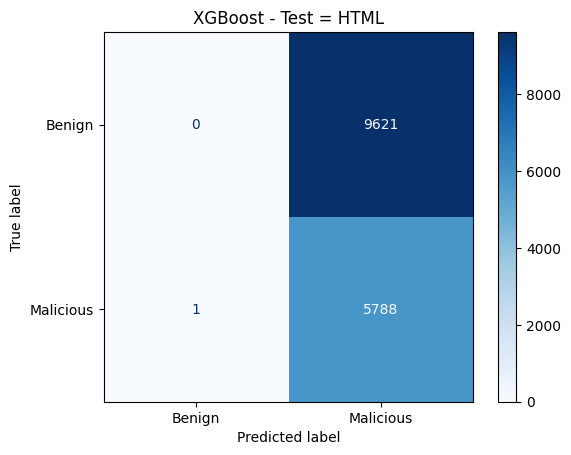


Final Results



,Test Format,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,HTML,Decision Tree,0.363076,0.364115,0.931767,0.523613,0.476329
1,HTML,Random Forest,0.375665,0.375665,1.000000,0.546158,0.322524
2,HTML,XGBoost,0.375600,0.375625,0.999827,0.546089,0.303255


In [ ]:


test_format = "HTML"      # PDF / Word / Excel / HTML

datasets = {
    "PDF": pdf_df,
    "Word": word_df,
    "Excel": excel_df,
    "HTML": html_df
}

#==================================================
# تجهيز بيانات التدريب والاختبار
#==================================================

train_list = [df for name, df in datasets.items() if name != test_format]
train_df = pd.concat(train_list, ignore_index=True)

test_df = datasets[test_format]

X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

#==================================================
# Models
#==================================================

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

#==================================================
# Training & Evaluation
#==================================================

for name, model in models.items():

    print("="*70)
    print(f"{name}  |  Test Format = {test_format}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    if roc is not None:
        print("ROC AUC  :", roc)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign","Malicious"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"{name} - Test = {test_format}")
    plt.show()

    results.append({
        "Test Format": test_format,
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    })

#==================================================
# Final Table
#==================================================

results_df = pd.DataFrame(results)

print("\nFinal Results\n")
display(results_df)